# **Fase B: Modelado optimizado**

## **Librerias**

In [1]:
import math
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

## **Carga y preparación de datos**

Se carga el dataset procesado `dataset_final.csv` y se ordenan los registros por `product_id` y `date`
para respetar la secuencia temporal.  
A continuación, se seleccionan las variables numéricas que alimentarán al modelo LSTM y se guarda la
lista de features para su uso posterior en producción.

In [2]:
def load_features(path):
    return pd.read_csv(path, parse_dates=["date"])

df = load_features("../data/processed/dataset_final.csv")
df = df.sort_values(["product_id", "date"]).reset_index(drop=True)

num_features = [
    "quantity_sold", 
    "stock_available", 
    "sales_mavg_7d",
    "ratio_sold_stock", 
    "price_per_unit"
]
joblib.dump(num_features, "../models/features_lstm_optimo.save")
print("Lista de features guardada como features_lstm_optimo.save")

Lista de features guardada como features_lstm_optimo.save


## **Escalado por productos**

Se aplica un escalado MinMax de 0 a 1 separado por `product_id`, de modo que cada producto tenga
su propio `scaler`.  
Esto evita que productos con distintos rangos de ventas distorsionen el entrenamiento y permite
normalizar correctamente las series temporales.  
Los objetos `scaler` se guardan en disco para reutilizarlos en el despliegue del modelo.

In [3]:
def scale_per_product(df, feature_cols):
    scalers = {}
    scaled_groups = []

    for pid, group in df.groupby("product_id"):
        scaler = MinMaxScaler()
        scaled_values = scaler.fit_transform(group[feature_cols])

        scaled_group = pd.DataFrame(scaled_values, columns=feature_cols)
        scaled_group["product_id"] = pid
        scaled_group["date"] = group["date"].values

        scalers[pid] = scaler
        scaled_groups.append(scaled_group)

    df_scaled = pd.concat(scaled_groups).sort_values(["product_id", "date"])
    df_scaled.reset_index(drop=True, inplace=True)

    return df_scaled, scalers

df_scaled, scalers = scale_per_product(df, num_features)
joblib.dump(scalers, "../models/scalers_lstm_optimo.save")
print("Escaladores guardados como scalers_lstm_optimo.save")

Escaladores guardados como scalers_lstm_optimo.save


## **Generación de secuencias temporales**

Se transforman las series temporales en secuencias de longitud fija (`seq_len = 10` días).  
Cada entrada `X` contiene los últimos 10 pasos de las variables seleccionadas y la salida `y`
corresponde al valor futuro de `quantity_sold`.  
De esta forma, el modelo aprende a predecir las ventas en función del comportamiento de los días anteriores.

In [4]:
def generate_sequences(df, feature_cols, seq_len):
    X, y = [], []

    for pid, group in df.groupby("product_id"):
        data = group[feature_cols].values
        for i in range(len(data) - seq_len):
            X.append(data[i:i+seq_len])
            y.append(data[i+seq_len, 0])  # target = quantity_sold

    return np.array(X), np.array(y)

SEQ_LEN = 10
X, y = generate_sequences(df_scaled, num_features, SEQ_LEN)
print("Secuencias generadas:", X.shape, y.shape)

Secuencias generadas: (1711, 10, 5) (1711,)


## **Definición y entrenamieto del modelo LSTM**

In [5]:
def temporal_split_3way(X, y, train_ratio=0.8, val_ratio=0.1):
    n = len(X)

    train_end = int(n * train_ratio)
    val_end = train_end + int(n * val_ratio)

    X_train = X[:train_end]
    y_train = y[:train_end]

    X_val = X[train_end:val_end]
    y_val = y[train_end:val_end]

    X_test = X[val_end:]
    y_test = y[val_end:]

    return X_train, X_val, X_test, y_train, y_val, y_test

def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.3),
        LSTM(64),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

TRAIN_SPLIT = 0.8
X_train, X_val, X_test, y_train, y_val, y_test = temporal_split_3way(X, y)
model = build_lstm_model((X_train.shape[1], X_train.shape[2]))


es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
rlrop = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
mc = ModelCheckpoint("../models/modelo_lstm_optimo.h5", monitor="val_loss", save_best_only=True)

history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=16,
    validation_data=(X_val, y_val),
    shuffle=False,
    callbacks=[es, rlrop, mc],
    verbose=1
)

Epoch 1/60
86/86 [==============================] - 2s 11ms/step - loss: 0.0586 - mae: 0.1985 - val_loss: 0.0457 - val_mae: 0.1760 - lr: 0.0010
Epoch 2/60
18/86 [=====>........................] - ETA: 0s - loss: 0.0501 - mae: 0.1842

/Users/andresmorocho/Downloads/Aprendizaje Automatico/Proyecto/venv/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


86/86 [==============================] - 1s 6ms/step - loss: 0.0516 - mae: 0.1883 - val_loss: 0.0430 - val_mae: 0.1690 - lr: 0.0010
Epoch 3/60
86/86 [==============================] - 1s 7ms/step - loss: 0.0508 - mae: 0.1869 - val_loss: 0.0413 - val_mae: 0.1646 - lr: 0.0010
Epoch 4/60
86/86 [==============================] - 1s 6ms/step - loss: 0.0502 - mae: 0.1855 - val_loss: 0.0410 - val_mae: 0.1638 - lr: 0.0010
Epoch 5/60
86/86 [==============================] - 1s 6ms/step - loss: 0.0500 - mae: 0.1856 - val_loss: 0.0415 - val_mae: 0.1650 - lr: 0.0010
Epoch 6/60
86/86 [==============================] - 1s 6ms/step - loss: 0.0503 - mae: 0.1857 - val_loss: 0.0430 - val_mae: 0.1687 - lr: 0.0010
Epoch 7/60
79/86 [==========================>...] - ETA: 0s - loss: 0.0507 - mae: 0.1866
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
86/86 [==============================] - 1s 7ms/step - loss: 0.0502 - mae: 0.1858 - val_loss: 0.0412 - val_mae: 0.1639 - lr: 0.0010

## **Evaluación del modelo(escala real)**

Tras el entrenamiento, se generan predicciones sobre el conjunto de prueba.
Luego, tanto las predicciones como los valores reales se desescalan utilizando el `scaler`
de un producto de referencia para volver a la unidad original (unidades vendidas).

Se calculan las métricas:
- **MAE (Mean Absolute Error)**: error promedio en unidades vendidas.
- **RMSE (Root Mean Squared Error)**: penaliza más los errores grandes.

Estas métricas permiten cuantificar el desempeño del modelo en términos interpretables
para el negocio (diferencia promedio entre ventas reales y predichas).

In [6]:
# Usar scaler de cualquier producto como referencia
pid = list(scalers.keys())[0]
scaler = scalers[pid]

y_pred = model.predict(X_test)

# Preparar columna 0 (quantity_sold)
y_pred_full = np.zeros((len(y_pred), len(num_features)))
y_test_full = np.zeros((len(y_test), len(num_features)))

y_pred_full[:, 0] = y_pred.flatten()
y_test_full[:, 0] = y_test.flatten()

# Desescalar
y_pred_real = scaler.inverse_transform(y_pred_full)[:, 0]
y_test_real = scaler.inverse_transform(y_test_full)[:, 0]

mae_real = mean_absolute_error(y_test_real, y_pred_real)
rmse_real = math.sqrt(mean_squared_error(y_test_real, y_pred_real))

print(f"MAE real: {mae_real:.2f}")
print(f"RMSE real: {rmse_real:.2f}")

6/6 [==============================] - 0s 2ms/step
MAE real: 16.61
RMSE real: 19.54


**Comparación entre valores reales y predichos (primeras 100 muestras)**

Se grafica la comparación entre las ventas reales y las predichas para las primeras 100 muestras
del conjunto de prueba.

La línea azul representa los valores reales, mostrando una serie más errática con picos pronunciados.
La línea naranja discontinua corresponde a las predicciones del modelo LSTM, que sigue la tendencia general
de las ventas pero suaviza las oscilaciones más extremas.

Esta visualización permite comprobar que el modelo captura adecuadamente el nivel y la forma global
de la serie, aunque, como es habitual en modelos de este tipo, tiende a subestimar los picos muy bruscos.

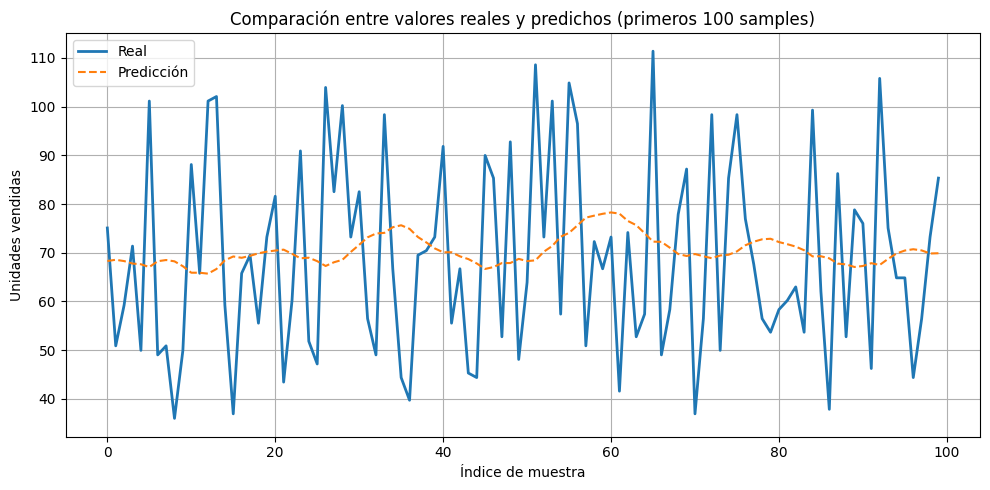

In [7]:
plt.figure(figsize=(10,5))
plt.plot(y_test_real[:100], label="Real", linewidth=2)
plt.plot(y_pred_real[:100], label="Predicción", linestyle="--")
plt.title("Comparación entre valores reales y predichos (primeros 100 samples)")
plt.xlabel("Índice de muestra")
plt.ylabel("Unidades vendidas")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Curvas de Entrenamiento**

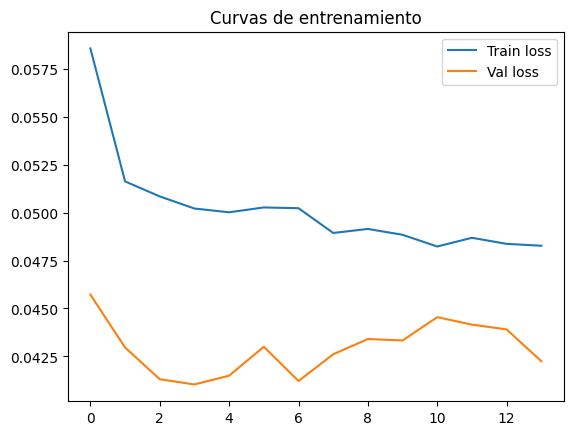

In [8]:
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Val loss")
plt.title("Curvas de entrenamiento")
plt.legend()
plt.show()

**Distribución de errores**

6/6 [==============================] - 0s 2ms/step


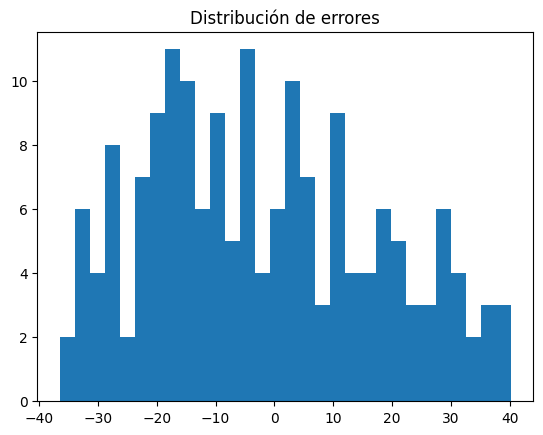

In [9]:
y_pred = model.predict(X_test)

# re-escalado seguro
scaler = list(scalers.values())[0]

y_pred_full = np.zeros((len(y_pred), len(num_features)))
y_test_full = np.zeros((len(y_test), len(num_features)))

y_pred_full[:, 0] = y_pred.flatten()
y_test_full[:, 0] = y_test.flatten()

y_pred_real = scaler.inverse_transform(y_pred_full)[:, 0]
y_test_real = scaler.inverse_transform(y_test_full)[:, 0]

errors = y_test_real - y_pred_real

plt.hist(errors, bins=30)
plt.title("Distribución de errores")
plt.show()

**Baseline**

In [10]:
baseline_pred = X_test[:, -1, 0]

# reescalar baseline
baseline_full = np.zeros((len(baseline_pred), len(num_features)))
baseline_full[:, 0] = baseline_pred

baseline_real = scaler.inverse_transform(baseline_full)[:, 0]

baseline_mae = mean_absolute_error(y_test_real, baseline_real)

print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"LSTM MAE: {mae_real:.2f}")

Baseline MAE: 22.73
LSTM MAE: 16.61
